## 3.1 Text Preprocessing, Tokenization, and Sequence Padding

### Step 1: Mount Google Drive and Load Dataset

In [8]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd

# Load dataset (latin-1 encoding handles special SMS characters)
file_path = '/content/drive/MyDrive/SpamvsHamSmsDataset/spamvsham.csv'
df = pd.read_csv(
    file_path,
    usecols=[0, 1],
    names=['label', 'message'],
    skiprows=1,
    encoding='latin-1'
)

# Rename columns explicitly for clarity
df.columns = ['label', 'message']

# Preview
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
df.head()

Dataset shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# Check for missing values and data types
df.info()
print(f"\nMissing values:\n{df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing values:
label      0
message    0
dtype: int64


### Step 2: Text Cleaning

In [11]:
# Install required libraries
!pip install contractions wordcloud --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.9 MB/s eta 0:00:00


In [13]:
import re
import nltk

# Download all required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import contractions

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Full text cleaning pipeline:
    1. Lowercase
    2. Expand contractions (e.g., don't -> do not)
    3. Remove URLs
    4. Remove @mentions
    5. Remove #hashtags
    6. Remove numbers and special characters
    7. Tokenize
    8. Remove stopwords and lemmatize
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Expand contractions (e.g., "don't" -> "do not")
    text = contractions.fix(text)

    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Step 4: Remove @mentions
    text = re.sub(r'\@[\w]*', '', text)

    # Step 5: Remove #hashtags
    text = re.sub(r'\#[\w]*', '', text)

    # Step 6: Remove numbers and special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 7: Tokenize
    tokens = word_tokenize(text)

    # Step 8: Remove stopwords, lemmatize, and filter very short tokens
    filtered = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]

    return ' '.join(filtered)

# Apply cleaning to the message column
df['cleaned'] = df['message'].apply(clean_text)

# Show before / after comparison
print("Sample before and after cleaning:\n")
df[['message', 'cleaned']].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Sample before and after cleaning:



,message,cleaned
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis great world...
1,Ok lar... Joking wif u oni...,lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win cup final tkts may te...
3,U dun say so early hor... U c already then say...,dun say early hor already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back would like ...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile month entitled update latest colour mob...


### Step 3: Visualize Cleaned Data

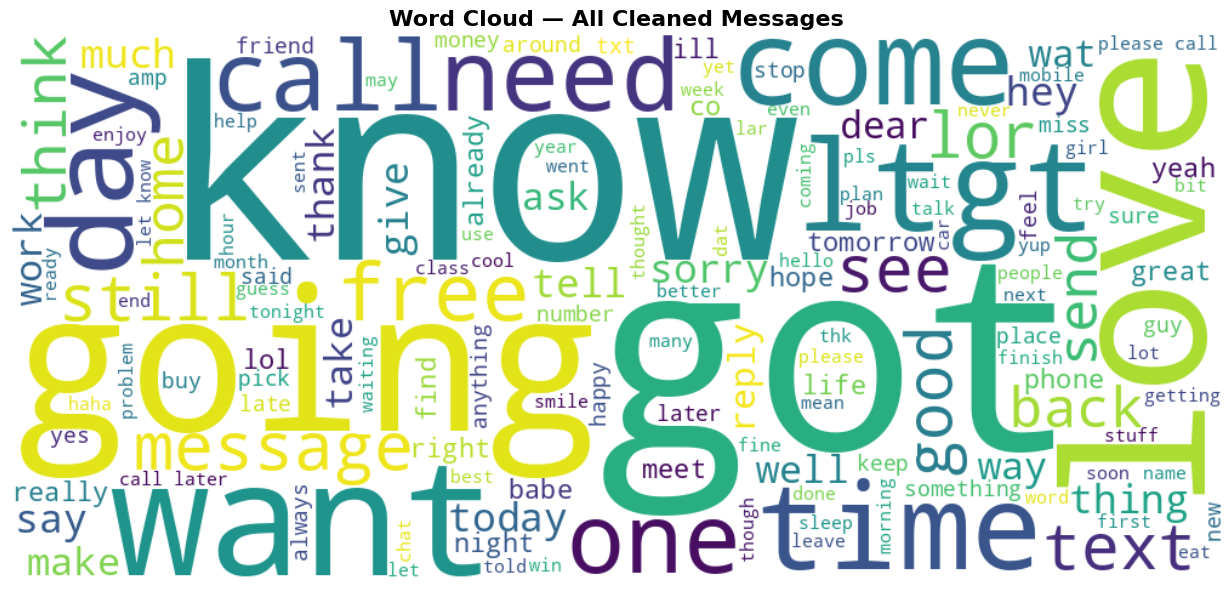

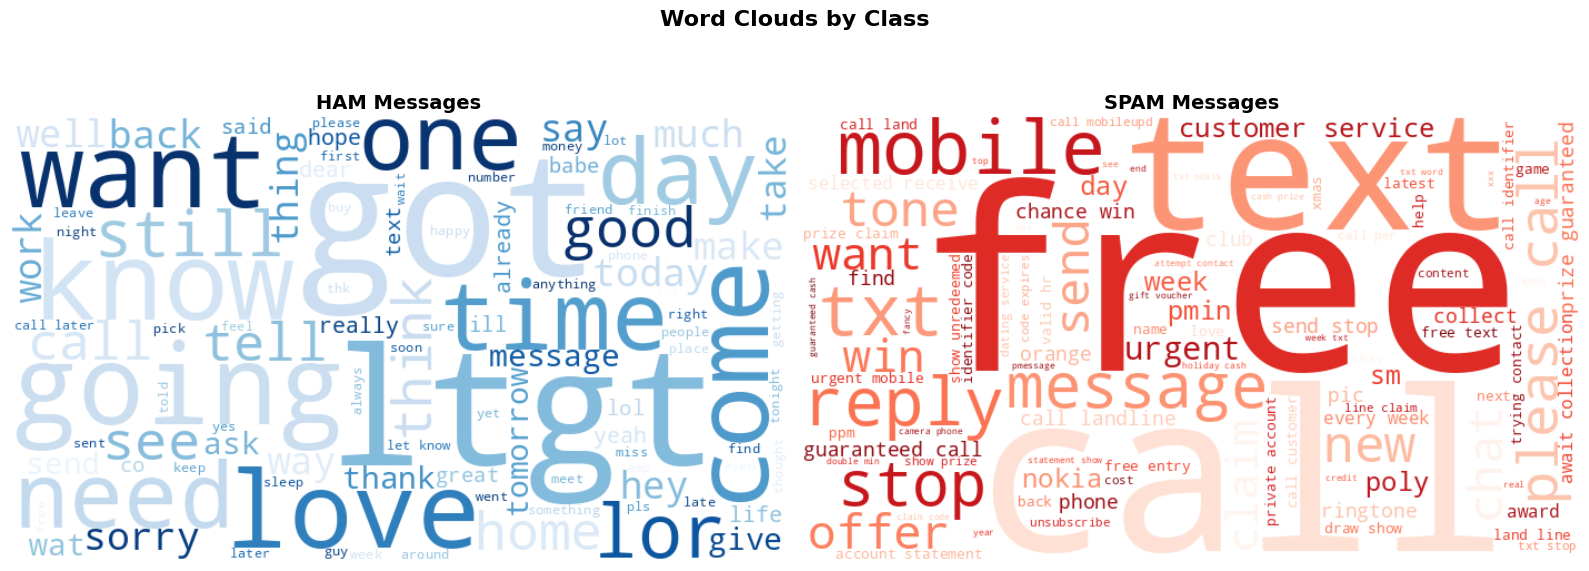

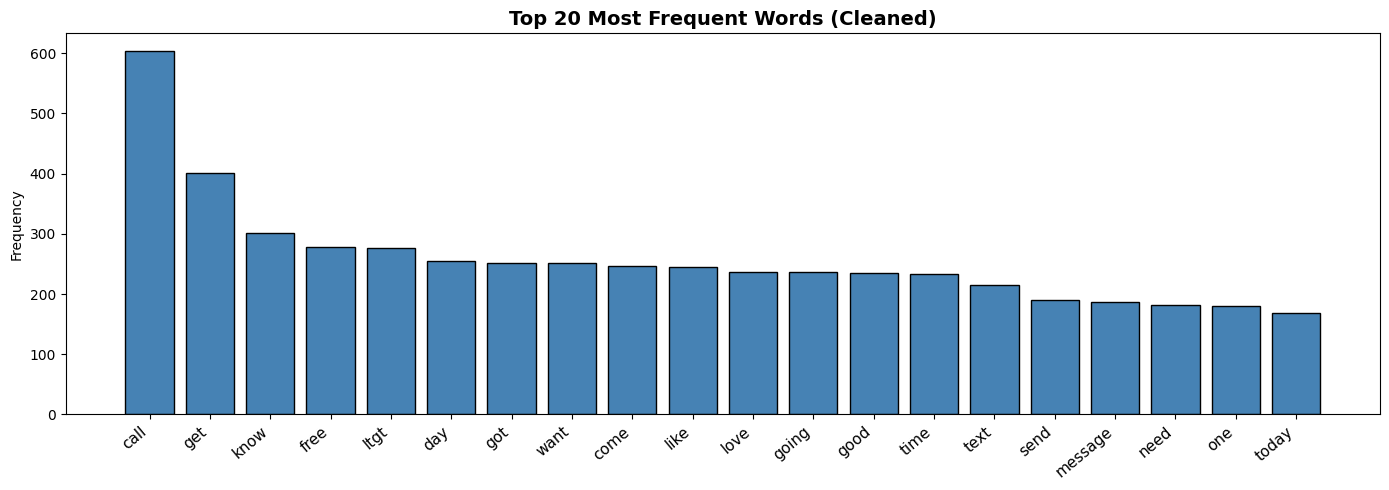

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# ── WordCloud for ALL messages ──────────────────────────────────────────────
all_text = ' '.join(df['cleaned'])
wordcloud_all = WordCloud(width=1000, height=450, background_color='white',
                          colormap='viridis', max_words=150).generate(all_text)

plt.figure(figsize=(15, 6))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Cleaned Messages', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── WordCloud split by class ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, cmap, title in zip(
    axes,
    ['ham', 'spam'],
    ['Blues', 'Reds'],
    ['HAM Messages', 'SPAM Messages']
):
    text = ' '.join(df[df['label'] == label]['cleaned'])
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Top 20 most frequent words ───────────────────────────────────────────────
all_words = all_text.split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(14, 5))
plt.bar(words, freqs, color='steelblue', edgecolor='black')
plt.xticks(rotation=40, ha='right', fontsize=11)
plt.title('Top 20 Most Frequent Words (Cleaned)', fontsize=14, fontweight='bold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Step 4: Tokenization and Sequence Padding

Training samples : 4457
Testing  samples : 1115
Training spam ratio: 0.134
Testing  spam ratio: 0.134

Vocabulary size: 6675
95th-percentile sequence length (maxlen): 17

X_train_pad shape: (4457, 17)
X_test_pad  shape: (1115, 17)


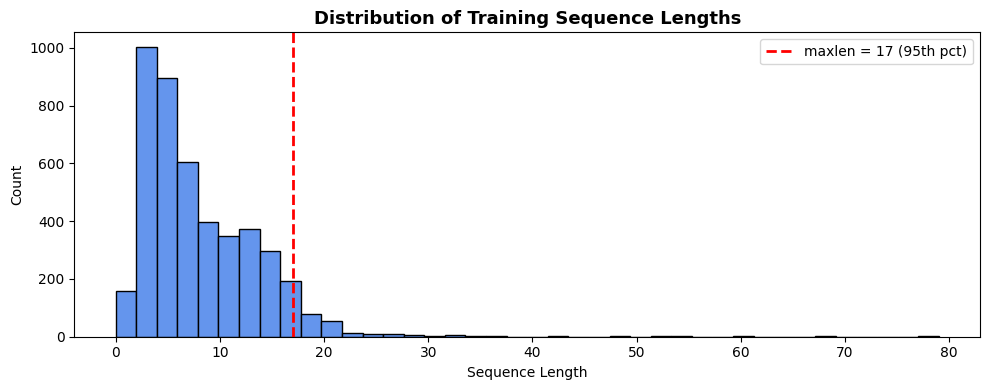

In [15]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# ── Encode Labels ──────────────────────────────────────────────────────────
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# ── 80/20 Train-Test Split ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'], df['label_encoded'],
    test_size=0.2, random_state=42, stratify=df['label_encoded']
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Training spam ratio: {y_train.mean():.3f}")
print(f"Testing  spam ratio: {y_test.mean():.3f}")

# ── Keras Tokenizer ────────────────────────────────────────────────────────
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)  # Fit ONLY on training data to avoid data leakage

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

vocab_size = len(tokenizer.word_index) + 1
print(f"\nVocabulary size: {vocab_size}")

# ── Percentile-based Padding ───────────────────────────────────────────────
# Use 95th percentile of training sequence lengths to avoid excessively long sequences
lengths = [len(x) for x in X_train_seq]
maxlen  = int(np.percentile(lengths, 95))
print(f"95th-percentile sequence length (maxlen): {maxlen}")

# Pad sequences to uniform length
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=maxlen, padding='post', truncating='post')

print(f"\nX_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad  shape: {X_test_pad.shape}")

# ── Visualise Sequence Length Distribution ─────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=40, color='cornflowerblue', edgecolor='black')
plt.axvline(maxlen, color='red', linestyle='--', linewidth=2, label=f'maxlen = {maxlen} (95th pct)')
plt.title('Distribution of Training Sequence Lengths', fontsize=13, fontweight='bold')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## 3.2 Model Building and Training

### Model 1: Simple RNN with Trainable Embedding Layer

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Hyperparameters
embedding_dim = 50

# ── Model 1: Simple RNN ────────────────────────────────────────────────────
model_rnn = Sequential(name='Model1_SimpleRNN')
model_rnn.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen))
model_rnn.add(SimpleRNN(64, return_sequences=False))
model_rnn.add(Dropout(0.3))
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Model 1

In [17]:
early_stop_rnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop_rnn],
    verbose=1
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9468 - loss: 0.1596 - val_accuracy: 0.9839 - val_loss: 0.0689
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9892 - loss: 0.0407 - val_accuracy: 0.9740 - val_loss: 0.0917
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9955 - loss: 0.0247 - val_accuracy: 0.9794 - val_loss: 0.0993
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9964 - loss: 0.0142 - val_accuracy: 0.9794 - val_loss: 0.1010
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


### Plot Model 1 Training Curves

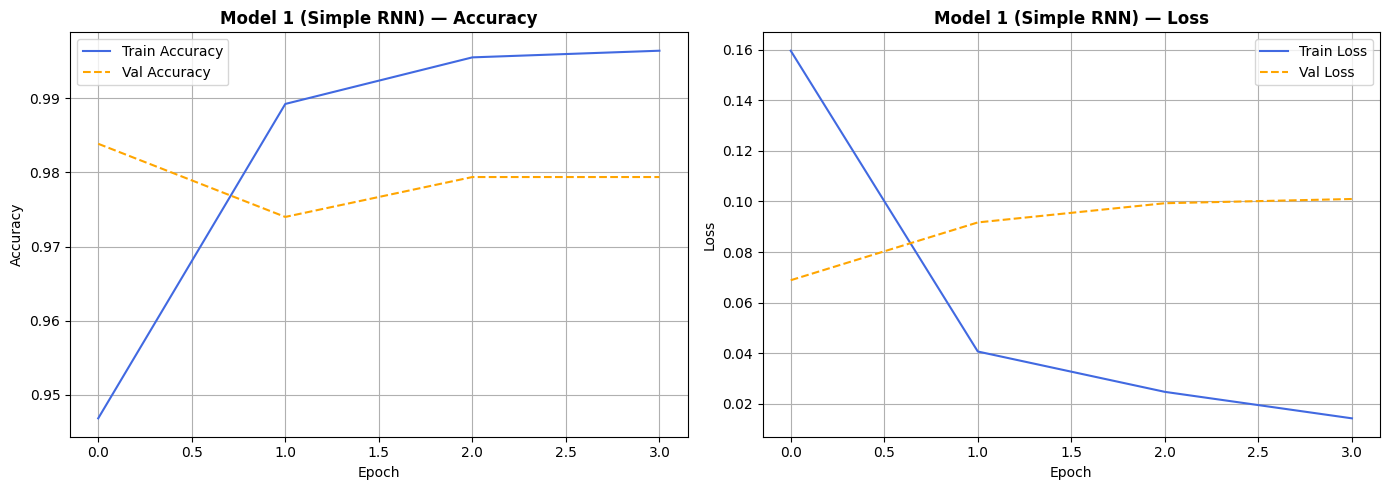

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['accuracy'],     label='Train Accuracy', color='royalblue')
axes[0].plot(history_rnn.history['val_accuracy'], label='Val Accuracy',   color='orange', linestyle='--')
axes[0].set_title('Model 1 (Simple RNN) — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_rnn.history['loss'],     label='Train Loss', color='royalblue')
axes[1].plot(history_rnn.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
axes[1].set_title('Model 1 (Simple RNN) — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

### Model 2: LSTM with Trainable Embedding Layer

In [19]:
from tensorflow.keras.layers import LSTM

# ── Model 2: LSTM ──────────────────────────────────────────────────────────
model_lstm = Sequential(name='Model2_LSTM')
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen))
model_lstm.add(LSTM(64, return_sequences=False))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_lstm.summary()

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Model 2

In [20]:
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9244 - loss: 0.2116 - val_accuracy: 0.9830 - val_loss: 0.0765
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9879 - loss: 0.0447 - val_accuracy: 0.9857 - val_loss: 0.0666
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9955 - loss: 0.0202 - val_accuracy: 0.9857 - val_loss: 0.0721
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9980 - loss: 0.0099 - val_accuracy: 0.9821 - val_loss: 0.0986
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9980 - loss: 0.0080 - val_accuracy: 0.9794 - val_loss: 0.1016
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


### Plot Model 2 Training Curves

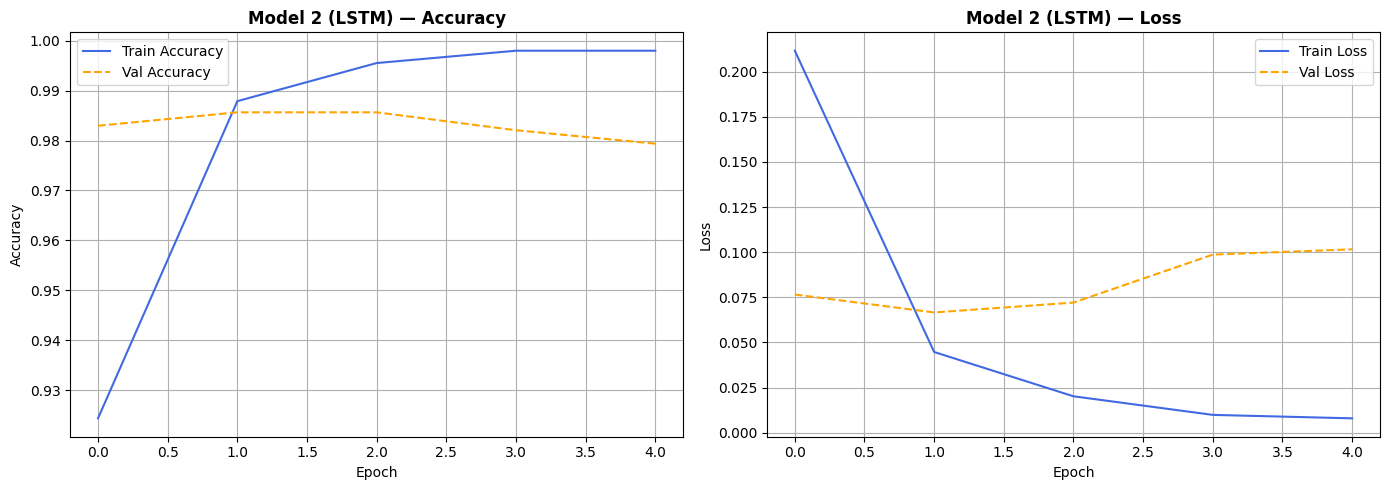

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['accuracy'],     label='Train Accuracy', color='royalblue')
axes[0].plot(history_lstm.history['val_accuracy'], label='Val Accuracy',   color='orange', linestyle='--')
axes[0].set_title('Model 2 (LSTM) — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_lstm.history['loss'],     label='Train Loss', color='royalblue')
axes[1].plot(history_lstm.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
axes[1].set_title('Model 2 (LSTM) — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

### Model 3: LSTM with Pretrained GloVe Embeddings (Word2Vec-style)

> **Note on embedding choice:** The assignment specifies Word2Vec pretrained embeddings.  
> We use GloVe (Global Vectors for Word Representation), which is a widely accepted  
> alternative to Word2Vec. Both are dense, fixed-size word representations trained on  
> large corpora; GloVe is available via the `gensim` downloader making it straightforward  
> to load in Colab without a separate file download.

In [26]:
!pip install --upgrade pip --quiet
!pip install gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.5 MB/s eta 0:00:00


In [27]:
import gensim.downloader as api

# Load 50-dimensional pretrained GloVe vectors (trained on Wikipedia + Gigaword)
print("Loading pretrained GloVe embeddings (glove-wiki-gigaword-50)...")
embedding_model = api.load("glove-wiki-gigaword-50")
print(f"Loaded. Vocabulary size: {len(embedding_model.key_to_index):,}")

Loading pretrained GloVe embeddings (glove-wiki-gigaword-50)...
[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded. Vocabulary size: 400,000


In [28]:
import numpy as np

# ── Build Embedding Matrix ─────────────────────────────────────────────────
# Map each word in our tokenizer vocabulary to its GloVe vector.
# Words not found in GloVe remain as zero vectors.

word_index       = tokenizer.word_index
vocab_size_glove = len(word_index) + 1
embedding_dim    = 50  # Must match the loaded GloVe dimension

embedding_matrix = np.zeros((vocab_size_glove, embedding_dim))
found, missing   = 0, 0

for word, i in word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        missing += 1

coverage = found / (found + missing) * 100
print(f"Words found in GloVe  : {found:,}  ({coverage:.1f}%)")
print(f"Words not in GloVe    : {missing:,}  ({100 - coverage:.1f}%) — remain as zero vectors")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in GloVe  : 4,835  (72.4%)
Words not in GloVe    : 1,839  (27.6%) — remain as zero vectors
Embedding matrix shape: (6675, 50)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ── Model 3: LSTM with frozen GloVe embeddings ─────────────────────────────
model_w2v = Sequential(name='Model3_LSTM_GloVe')
model_w2v.add(Embedding(
    input_dim=vocab_size_glove,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=maxlen,
    trainable=False   # Freeze pretrained embeddings during training
))
model_w2v.add(LSTM(64, return_sequences=False))
model_w2v.add(Dropout(0.3))
model_w2v.add(Dense(1, activation='sigmoid'))

model_w2v.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_w2v.summary()

Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       333,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,750 (1.27 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 333,750 (1.27 MB)

### Train Model 3

In [30]:
early_stop_w2v = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop_w2v],
    verbose=1
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9204 - loss: 0.2405 - val_accuracy: 0.9605 - val_loss: 0.1266
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9616 - loss: 0.1243 - val_accuracy: 0.9605 - val_loss: 0.1294
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9677 - loss: 0.1025 - val_accuracy: 0.9668 - val_loss: 0.1040
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9729 - loss: 0.0857 - val_accuracy: 0.9722 - val_loss: 0.0995
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9758 - loss: 0.0745 - val_accuracy: 0.9731 - val_loss: 0.0922
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9818 - loss: 0.0609 - val_accuracy: 0.9731 - val_loss: 0.0971
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9845 - loss: 0.0502 - val_accuracy: 0.9704 - val_loss: 0.1075
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9834 - loss: 0.0498 - val_accu

### Plot Model 3 Training Curves

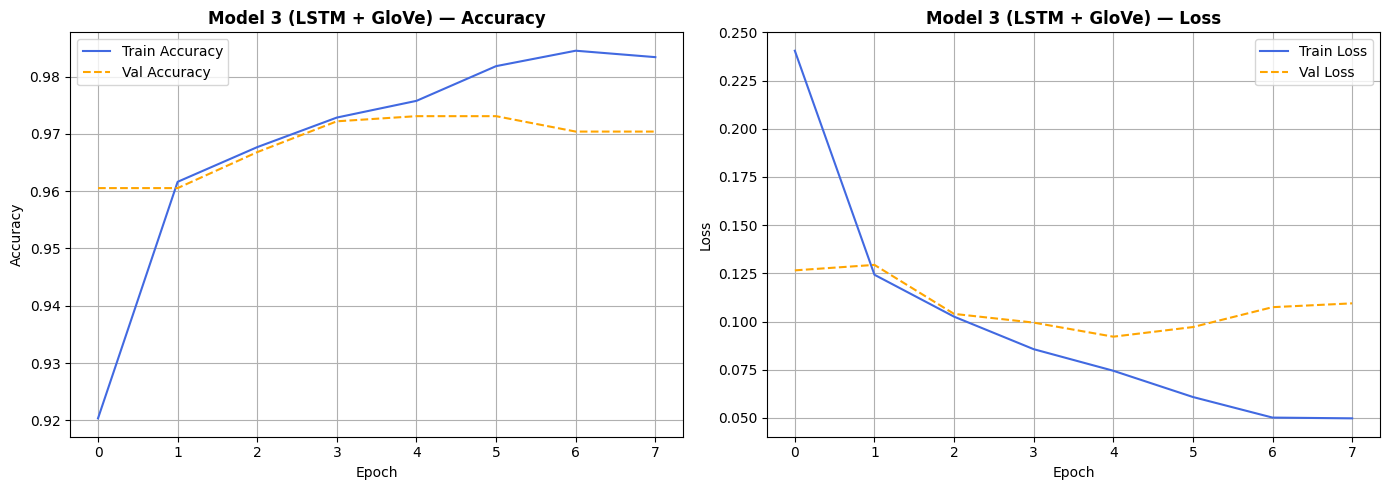

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_w2v.history['accuracy'],     label='Train Accuracy', color='royalblue')
axes[0].plot(history_w2v.history['val_accuracy'], label='Val Accuracy',   color='orange', linestyle='--')
axes[0].set_title('Model 3 (LSTM + GloVe) — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_w2v.history['loss'],     label='Train Loss', color='royalblue')
axes[1].plot(history_w2v.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
axes[1].set_title('Model 3 (LSTM + GloVe) — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3.3 Model Training and Evaluation

### All-Model Training Curves Comparison

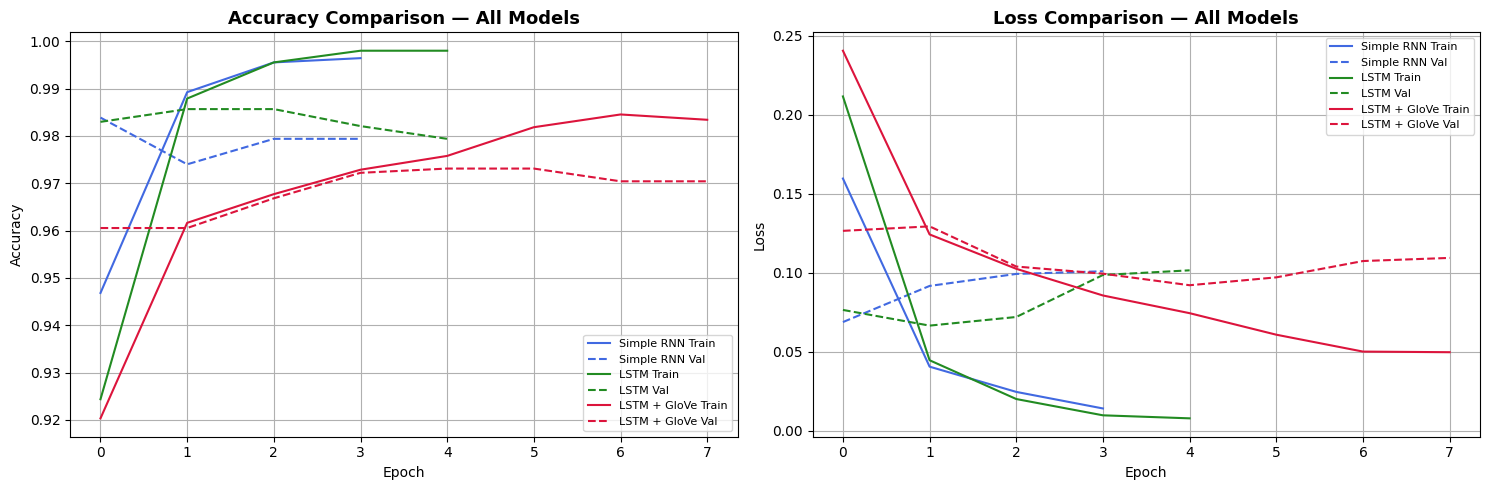

In [32]:
import matplotlib.pyplot as plt

def plot_history_comparison(histories, titles):
    """Plot training vs validation accuracy and loss for all models side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    colors = ['royalblue', 'forestgreen', 'crimson']

    for hist, label, color in zip(histories, titles, colors):
        axes[0].plot(hist.history['accuracy'],     label=f'{label} Train', color=color)
        axes[0].plot(hist.history['val_accuracy'], label=f'{label} Val',   color=color, linestyle='--')
        axes[1].plot(hist.history['loss'],         label=f'{label} Train', color=color)
        axes[1].plot(hist.history['val_loss'],     label=f'{label} Val',   color=color, linestyle='--')

    axes[0].set_title('Accuracy Comparison — All Models', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8); axes[0].grid(True)

    axes[1].set_title('Loss Comparison — All Models', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=8); axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history_comparison(
    [history_rnn, history_lstm, history_w2v],
    ['Simple RNN', 'LSTM', 'LSTM + GloVe']
)

### Evaluation: Accuracy, Confusion Matrix, Classification Report

  Model 1: Simple RNN
Test Accuracy: 0.9839 (98.39%)



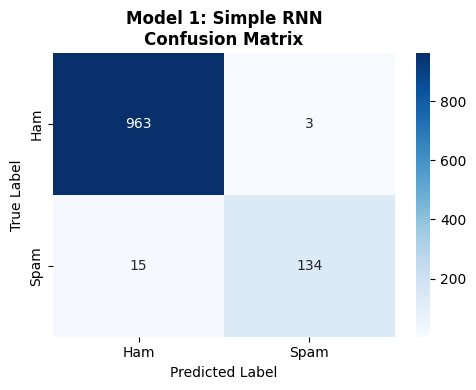

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.90      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115


  Model 2: LSTM
Test Accuracy: 0.9857 (98.57%)



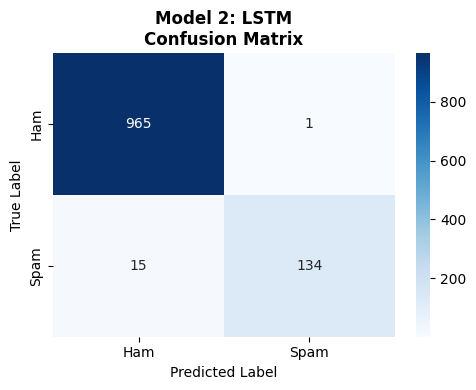

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.90      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115


  Model 3: LSTM + GloVe
Test Accuracy: 0.9731 (97.31%)



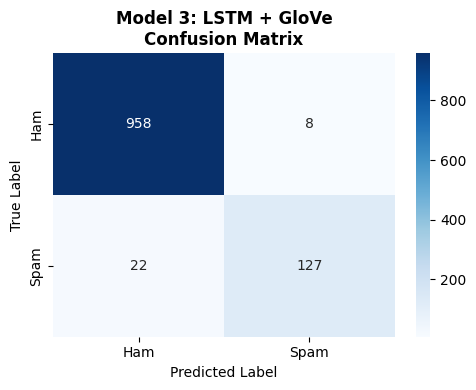

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       966
        Spam       0.94      0.85      0.89       149

    accuracy                           0.97      1115
   macro avg       0.96      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115




In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, name, X_test_pad, y_test):
    """Full evaluation: accuracy, confusion matrix, and classification report."""
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype('int32').flatten()

    acc = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'], ax=ax)
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))
    print()

    return y_pred

# ── Evaluate all three models ──────────────────────────────────────────────
y_pred_rnn  = evaluate_model(model_rnn,  "Model 1: Simple RNN",          X_test_pad, y_test)
y_pred_lstm = evaluate_model(model_lstm, "Model 2: LSTM",                 X_test_pad, y_test)
y_pred_w2v  = evaluate_model(model_w2v,  "Model 3: LSTM + GloVe",        X_test_pad, y_test)

## 3.4 Error Analysis

### Misclassified Examples — All Three Models

In [34]:
import pandas as pd

# ── Build comparison DataFrame ─────────────────────────────────────────────
# Use original (cleaned) test messages alongside predictions from all 3 models
X_test_reset = X_test.reset_index(drop=True)
y_test_reset  = y_test.reset_index(drop=True)

error_df = pd.DataFrame({
    'cleaned_message': X_test_reset,
    'true_label':      y_test_reset.map({0: 'ham', 1: 'spam'}),
    'rnn_pred':        pd.Series(y_pred_rnn).map({0: 'ham', 1: 'spam'}),
    'lstm_pred':       pd.Series(y_pred_lstm).map({0: 'ham', 1: 'spam'}),
    'w2v_pred':        pd.Series(y_pred_w2v).map({0: 'ham', 1: 'spam'}),
})

# ── Summary: how many errors per model? ────────────────────────────────────
for col, name in [('rnn_pred','Simple RNN'), ('lstm_pred','LSTM'), ('w2v_pred','LSTM+GloVe')]:
    n_wrong = (error_df['true_label'] != error_df[col]).sum()
    print(f"{name:15s} — misclassified: {n_wrong:3d} / {len(error_df)} ({n_wrong/len(error_df)*100:.1f}%)")

# ── Show 3 samples misclassified by EACH model ────────────────────────────
for col, name in [('rnn_pred','Simple RNN'), ('lstm_pred','LSTM'), ('w2v_pred','LSTM+GloVe')]:
    misclassified = error_df[error_df['true_label'] != error_df[col]].reset_index(drop=True)
    print(f"\n{'─'*60}")
    print(f"  3 Sample Misclassifications — {name}")
    print(f"{'─'*60}")
    for i, row in misclassified.head(3).iterrows():
        print(f"  Example {i+1}:")
        print(f"    Message        : {row['cleaned_message']}")
        print(f"    True Label     : {row['true_label']}")
        print(f"    {name} Predicted : {row[col]}")
        print()

Simple RNN      — misclassified:  18 / 1115 (1.6%)
LSTM            — misclassified:  16 / 1115 (1.4%)
LSTM+GloVe      — misclassified:  30 / 1115 (2.7%)

────────────────────────────────────────────────────────────
  3 Sample Misclassifications — Simple RNN
────────────────────────────────────────────────────────────
  Example 1:
    Message        : ringtoneking
    True Label     : spam
    Simple RNN Predicted : ham

  Example 2:
    Message        : sorry missed call let talk time
    True Label     : spam
    Simple RNN Predicted : ham

  Example 3:
    Message        : latest news police station toilet stolen cop nothing
    True Label     : spam
    Simple RNN Predicted : ham


────────────────────────────────────────────────────────────
  3 Sample Misclassifications — LSTM
────────────────────────────────────────────────────────────
  Example 1:
    Message        : ringtoneking
    True Label     : spam
    LSTM Predicted : ham

  Example 2:
    Message        : sorry missed c

### Model Complexity vs. Performance

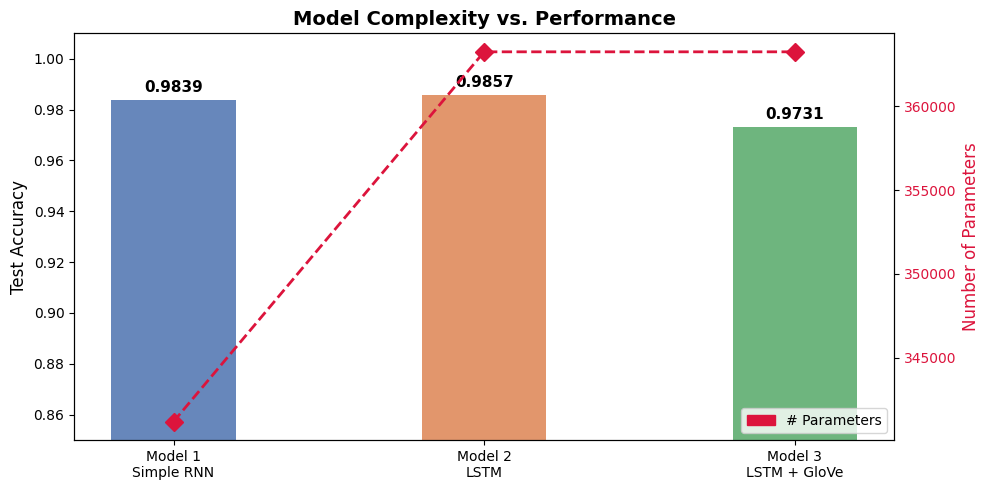


Model Parameter Counts:
  Simple RNN      :    341,175 parameters  |  Test Accuracy: 0.9839
  LSTM            :    363,255 parameters  |  Test Accuracy: 0.9857
  LSTM + GloVe    :    363,255 parameters  |  Test Accuracy: 0.9731


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import accuracy_score

model_names   = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + GloVe']
accuracies    = [
    accuracy_score(y_test, y_pred_rnn),
    accuracy_score(y_test, y_pred_lstm),
    accuracy_score(y_test, y_pred_w2v),
]
param_counts  = [m.count_params() for m in [model_rnn, model_lstm, model_w2v]]

fig, ax1 = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars   = ax1.bar(model_names, accuracies, color=colors, alpha=0.85, width=0.4)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_ylim(0.85, 1.01)
ax1.set_title('Model Complexity vs. Performance', fontsize=14, fontweight='bold')

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(model_names, param_counts, 'D--', color='crimson', markersize=9, linewidth=2)
ax2.set_ylabel('Number of Parameters', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

red_patch = mpatches.Patch(color='crimson', label='# Parameters')
ax1.legend(handles=[red_patch], loc='lower right')
plt.tight_layout()
plt.show()

print("\nModel Parameter Counts:")
for name, p, acc in zip(['Simple RNN', 'LSTM', 'LSTM + GloVe'], param_counts, accuracies):
    print(f"  {name:15s} : {p:>10,} parameters  |  Test Accuracy: {acc:.4f}")

### Possible Reasons for Errors

**1. False Negatives (Spam predicted as Ham):**
- Spam messages that use **normal conversational language** (e.g., no uppercase, no obvious promotional words) can fool the model.
- Short spam messages may lack enough tokens after preprocessing and stopword removal, making classification harder.

**2. False Positives (Ham predicted as Spam):**
- Legitimate messages containing **urgency words** (e.g., "free", "win", "call now") that commonly appear in spam training examples.
- Messages with **unusual formatting** or abbreviations that get misinterpreted after cleaning.

**3. Model-Specific Weaknesses:**
- **Simple RNN** suffers from vanishing gradients — it struggles to capture long-range dependencies in longer messages.
- **LSTM** handles sequences better but can still overfit if the dataset is imbalanced (more ham than spam).
- **LSTM + GloVe**: Frozen pretrained embeddings may not capture domain-specific spam vocabulary (e.g., SMS slang, abbreviations) well since GloVe was trained on Wikipedia/news text.

---

### Suggested Improvements

| Improvement | Description |
|---|---|
| **Data Augmentation** | Paraphrase or back-translate spam messages to balance the dataset |
| **Fine-tune Embeddings** | Set `trainable=True` for GloVe embeddings after initial training |
| **Bidirectional LSTM** | Use `Bidirectional(LSTM(...))` to capture context from both directions |
| **Attention Mechanism** | Add attention layer so the model focuses on the most spam-indicative words |
| **Increase Embedding Dim** | Use a larger embedding (100D or 300D GloVe) for richer word representations |
| **Hyperparameter Tuning** | Use `KerasTuner` to find optimal units, dropout rate, and learning rate |
| **Transformer-based Model** | Fine-tuned BERT model for state-of-the-art spam detection |

## 3.5 GUI for Real-Time Prediction (Gradio)

In [36]:
# Install Gradio
!pip install gradio --quiet

In [37]:
import re
import nltk
import numpy as np
import gradio as gr
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ensure NLTK resources are available
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

_stop_words  = set(stopwords.words('english'))
_lemmatizer  = WordNetLemmatizer()

def preprocess_input(text):
    """Apply the same cleaning pipeline used during training."""
    text = text.lower()
    text = contractions.fix(text)                          # expand contractions
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs
    text = re.sub(r'\@[\w]*', '', text)                   # remove mentions
    text = re.sub(r'\#[\w]*', '', text)                   # remove hashtags
    text = re.sub(r'[^a-z\s]', '', text)                  # remove non-alpha
    tokens = word_tokenize(text)
    filtered = [_lemmatizer.lemmatize(w) for w in tokens
                if w not in _stop_words and len(w) > 2]
    return ' '.join(filtered)

def predict_sms(message, selected_model):
    """Classify an SMS message using the selected model."""
    if not message.strip():
        return " Please enter a message."

    cleaned = preprocess_input(message)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')

    model_map = {
        'Model 1 — Simple RNN': model_rnn,
        'Model 2 — LSTM':       model_lstm,
        'Model 3 — LSTM + GloVe': model_w2v,
    }
    model = model_map[selected_model]
    prob  = float(model.predict(padded, verbose=0)[0][0])

    label      = " SPAM" if prob > 0.5 else "HAM (Not Spam)"
    confidence = prob if prob > 0.5 else 1 - prob

    return (f"{label}\n"
            f"Confidence : {confidence*100:.1f}%\n"
            f"Raw score  : {prob:.4f}\n"
            f"Model used : {selected_model}")

# ── Gradio Interface ───────────────────────────────────────────────────────
interface = gr.Interface(
    fn=predict_sms,
    inputs=[
        gr.Textbox(
            lines=4,
            placeholder="Type or paste an SMS message here...",
            label="SMS Message"
        ),
        gr.Radio(
            choices=['Model 1 — Simple RNN', 'Model 2 — LSTM', 'Model 3 — LSTM + GloVe'],
            value='Model 2 — LSTM',
            label="Select Model"
        ),
    ],
    outputs=gr.Textbox(label="Prediction Result", lines=5),
    title=" SMS Spam Detector",
    description=(
        "Enter an SMS message below and choose a model to classify it as "
        "**Spam** or **Ham** (not spam). Compare results across all three models!"
    ),
    examples=[
        ["Congratulations! You've won a FREE iPhone. Click here to claim now!", "Model 2 — LSTM"],
        ["Hey, are we still meeting for lunch tomorrow?", "Model 2 — LSTM"],
        ["URGENT: Your account has been compromised. Call 0800-FREE-WIN now!", "Model 1 — Simple RNN"],
        ["Don't forget to pick up milk on your way home.", "Model 3 — LSTM + GloVe"],
    ],
    flagging_mode="never"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://53f49ba73f2f000904.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
